# `01_Deep_Learning_Basics.ipynb`

## Dataset Used

I am using the **Online Retail transaction dataset** 

Important columns include:

- `InvoiceNo` – transaction/invoice number
- `StockCode` – product code
- `Description` – product description
- `Quantity` – number of items purchased
- `InvoiceDate` – transaction date and time
- `UnitPrice` – price per item
- `CustomerID` – customer identifier
- `Country` – customer's country

For the practical section, I will create a simple classification target:

**`IsWeekend`**
- `1` → transaction happened on Saturday or Sunday
- `0` → transaction happened on another day

I will deliberately avoid using the day/weekend information itself as an input feature. This keeps the demonstration conceptually cleaner.

The dataset is loaded from `data.csv`, matching the file name used in my previous notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="latin1")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



### Why this dataset is useful for learning Deep Learning

Deep learning models can also work with tabular data after preprocessing, although neural networks are especially popular for areas such as images, text, audio and other high-dimensional data.

For this notebook, the retail dataset gives me a familiar dataset on which I can demonstrate the basic neural-network ideas.

# 1. What is Deep Learning?

### Definition

**Deep Learning is a branch of Machine Learning that uses neural networks with multiple layers to learn patterns from data.**

In simple words:

> Instead of manually telling the computer every rule, I give it examples and the neural network learns useful patterns by adjusting its parameters.

The word **deep** mainly refers to having multiple layers between the input and output.

### My understanding

I think of Deep Learning as a system that learns a sequence of transformations.

For example:

**Image → edges → shapes → objects → final prediction**

The early layers may learn simple patterns, while later layers can combine those patterns into more meaningful information.

### Real-world analogy

Imagine teaching someone to recognize a cat.

Instead of giving a complete list of rules such as:

- four legs
- two ears
- whiskers
- tail
- fur

we show many examples.

With enough examples, the learner gradually discovers useful patterns.

A neural network works in a similar learning-based way.

### AI/ML usage

Deep Learning is widely used for:

- Image classification
- Object detection
- Face recognition
- Speech recognition
- Machine translation
- Chatbots and language models
- Recommendation systems
- Medical image analysis
- Time-series and forecasting problems

In [2]:
# A very small neural-network-style calculation

inputs = np.array([2.0, 3.0])
weights = np.array([0.5, 0.2])
bias = 0.1

weighted_sum = np.dot(inputs, weights) + bias

print("Weighted sum:", weighted_sum)

Weighted sum: 1.7000000000000002


### Result explanation

The code performs the basic mathematical operation used inside a neuron:

**output before activation = inputs × weights + bias**

For these values:

`(2 × 0.5) + (3 × 0.2) + 0.1 = 1.7`

This is not a complete deep-learning model yet. It is the smallest building block that helps me understand how a neural network starts processing information.

# 2. AI vs ML vs Deep Learning

These three terms are related, but they are not identical.

### Artificial Intelligence (AI)

AI is the broad field of making machines perform tasks that normally require human-like intelligence.

Examples:

- Reasoning
- Decision making
- Language understanding
- Vision
- Planning

### Machine Learning (ML)

Machine Learning is a subset of AI.

Instead of explicitly programming every rule, the system learns patterns from data.

Examples:

- Spam detection
- Customer churn prediction
- House-price prediction
- Fraud detection

### Deep Learning (DL)

Deep Learning is a subset of Machine Learning.

It uses neural networks with one or more hidden layers and can learn complex representations from large amounts of data.

### Simple relationship

**AI**
→ includes **Machine Learning**
→ includes **Deep Learning**

### Real-world analogy

Think of three circles:

- **AI** = the whole field
- **ML** = one approach used inside AI
- **Deep Learning** = a specific ML approach based on neural networks

### AI/ML usage

A project can be described at different levels:

- A chatbot is an **AI application**.
- If it learns patterns from data, it may use **ML**.
- If its language system is based on a large neural network, it uses **Deep Learning**.

# 3. Traditional ML vs Deep Learning

| Traditional Machine Learning | Deep Learning |
|---|---|
| Often depends more on manually designed features | Can learn useful representations automatically |
| Usually works well with structured/tabular data | Very strong for images, text, audio and complex data |
| Often works with smaller datasets | Often benefits from large datasets |
| Models can be easier to interpret | Deep networks can be harder to interpret |
| Training can be lighter | Training can require more computation |
| Examples: Decision Tree, Random Forest, Logistic Regression | Examples: CNN, RNN, Transformer, MLP |

### My understanding

The main difference I want to remember is:

> **Traditional ML often needs more human-designed features, while Deep Learning can learn multiple levels of representation directly from data.**

This does not mean Deep Learning is always better. The appropriate method depends on the problem, data, resources and requirements.

### Real-world analogy

Suppose I want to identify fruits.

**Traditional ML approach:**
I manually create features such as:

- weight
- color
- size
- roundness

Then the model learns from those features.

**Deep Learning approach:**
For an image, the neural network can learn useful visual patterns directly from pixel data.

### AI/ML usage

Feature engineering is still important in many ML projects. Deep Learning reduces some manual feature engineering, but preprocessing, data quality and problem understanding remain important.

# 4. Why are Neural Networks Required?

### Definition

A **Neural Network** is a computational model made of connected neurons arranged in layers.

It is useful because it can learn **non-linear and complex relationships** between inputs and outputs.

### Why simple rules may not be enough

Some real-world relationships are complicated.

For example, recognizing a face depends on combinations of:

- edges
- shapes
- eyes
- nose
- mouth
- relative positions
- lighting
- orientation

Writing every possible rule manually would be difficult.

A neural network can learn these relationships from examples.

### Real-world analogy

Imagine learning to identify a person's handwriting.

You do not consciously calculate every pixel.

Instead, your brain gradually recognizes:

**lines → curves → letters → words**

A multi-layer neural network can learn a similar hierarchy of representations.

### AI/ML usage

Neural networks are used in:

- Computer vision
- NLP
- Speech recognition
- Recommendation systems
- Forecasting
- Classification
- Regression
- Generative AI

### Simple demonstration

The following function shows a non-linear relationship. A neural network can learn complicated functions by combining many neurons and activation functions.

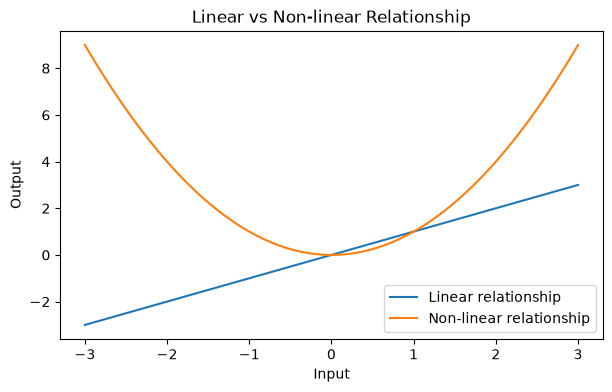

In [3]:
x = np.linspace(-3, 3, 100)

linear = x
non_linear = x**2

plt.figure(figsize=(7, 4))
plt.plot(x, linear, label="Linear relationship")
plt.plot(x, non_linear, label="Non-linear relationship")
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Linear vs Non-linear Relationship")
plt.legend()
plt.show()

### Result explanation

The straight line is a simple linear relationship.

The curved line is non-linear.

Neural networks use activation functions and multiple layers to learn much more complicated non-linear relationships than a single linear calculation can represent.

# 5. Applications of Deep Learning

Deep Learning is useful when the input contains complicated patterns that are difficult to describe with simple rules.

### Computer Vision

Examples:

- Image classification
- Object detection
- Face recognition
- Medical image analysis
- OCR

### Natural Language Processing

Examples:

- Text classification
- Translation
- Question answering
- Summarization
- Chatbots
- Large Language Models

### Speech and Audio

Examples:

- Speech-to-text
- Voice assistants
- Speaker recognition
- Audio classification

### Recommendation Systems

Deep models can learn relationships between users, products and behavior.

### Generative AI

Deep neural networks are used to generate:

- Text
- Images
- Audio
- Video
- Code

### Real-world analogy

Deep Learning is like a very flexible pattern-recognition system.

If the problem contains many interacting patterns, a sufficiently trained neural network can learn combinations of those patterns.

### AI/ML usage

The model architecture depends on the data:

- **CNNs** → images and spatial patterns
- **RNNs/LSTMs** → sequential data
- **Transformers** → language and many sequence-based tasks
- **Autoencoders** → representation learning and anomaly detection
- **MLPs** → general-purpose neural networks, including tabular data

# 6. Supervised Deep Learning

### Definition

In **Supervised Deep Learning**, the model learns from examples where the correct answer (label/target) is already known.

The basic idea is:

**Input → Neural Network → Prediction**

Then the prediction is compared with the known target.

**Prediction + Target → Loss → Parameter update**

This process is repeated many times during training.

### Real-world analogy

A teacher gives a student questions along with correct answers.

The student:

1. attempts an answer
2. compares it with the correct answer
3. learns from the difference
4. improves over time

A supervised neural network follows a similar idea.

### Examples

- Image → cat/dog
- Customer data → churn/not churn
- Transaction data → fraud/not fraud
- Patient data → diagnosis category
- House features → predicted price

### AI/ML usage

Supervised deep learning is used for:

- Classification
- Regression
- Object recognition
- Speech recognition
- Text classification
- Forecasting

In [4]:
# Create a simple supervised-learning example

study_hours = np.array([1, 2, 3, 4, 5])
passed = np.array([0, 0, 0, 1, 1])

supervised_example = pd.DataFrame({
    "StudyHours": study_hours,
    "Passed": passed
})

display(supervised_example)

,StudyHours,Passed
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1


### Result explanation

Here:

- `StudyHours` is the **input feature**.
- `Passed` is the **known target/label**.

Because the correct output is available during training, this is a supervised learning problem.

The same structure applies to a neural network:

**Features → Model → Predicted label**

# 7. Unsupervised Deep Learning

### Definition

In **Unsupervised Deep Learning**, the model works with data where there is no target label supplied for every example.

The model tries to discover useful structure or representations from the data.

Common approaches include:

- Autoencoders
- Representation learning
- Deep clustering approaches

### Real-world analogy

Imagine giving a box of mixed objects to a person without telling them the categories.

They may naturally group similar objects together:

- round objects
- electronic objects
- stationery
- toys

The system is discovering structure rather than learning from predefined answers.

### AI/ML usage

Unsupervised/deep representation learning can be used for:

- Anomaly detection
- Dimensionality reduction
- Data compression
- Feature learning
- Customer segmentation
- Similarity learning
- Pattern discovery

### Simple demonstration using our retail data

We can look at transaction behavior without using a target label.

In [5]:
# Select a few numerical transaction variables for an unsupervised view

unsupervised_data = df[["Quantity", "UnitPrice"]].copy()
unsupervised_data = unsupervised_data.replace([np.inf, -np.inf], np.nan).dropna()

unsupervised_data = unsupervised_data[
    (unsupervised_data["Quantity"] > 0) &
    (unsupervised_data["UnitPrice"] > 0)
].head(5000)

display(unsupervised_data.head())
print("Rows used:", len(unsupervised_data))

,Quantity,UnitPrice
0,6,2.55
1,6,3.39
2,8,2.75
3,6,3.39
4,6,3.39


Rows used: 5000


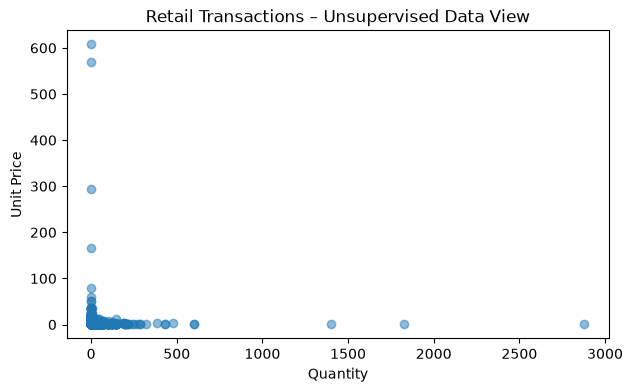

In [6]:
# A simple scatter plot to visually inspect natural structure

plt.figure(figsize=(7, 4))
plt.scatter(
    unsupervised_data["Quantity"],
    unsupervised_data["UnitPrice"],
    alpha=0.5
)
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Retail Transactions – Unsupervised Data View")
plt.show()

### Result explanation

There is no `y` target in this demonstration.

I am simply examining how transactions are distributed based on two numerical variables.

A deep unsupervised model such as an **autoencoder** could learn a compact representation of many such features without needing a predefined class label.

This is different from supervised learning, where the model receives the expected answer during training.

# 8. Neural Network Terminology

Before implementing a neural network, I need to understand its building blocks.

The basic flow is:

**Input Layer → Hidden Layer(s) → Output Layer**

Inside each neuron:

**Inputs → Weighted Sum + Bias → Activation → Output**

The important terms are explained below.

## 8.1 Neuron

### Definition

A **neuron** is a basic computational unit of a neural network.

It receives inputs, applies weights, adds a bias, and then passes the result through an activation function.

A simplified formula is:

**z = w₁x₁ + w₂x₂ + ... + b**

Then:

**output = activation(z)**

### Real-world analogy

Think of a neuron as a small decision maker.

It receives several pieces of information, gives different importance to each one, combines them, and produces an output.

### Python demonstration

In [7]:
inputs = np.array([2.0, 3.0])
weights = np.array([0.5, 0.2])
bias = 0.1

z = np.dot(inputs, weights) + bias

print("Inputs:", inputs)
print("Weights:", weights)
print("Bias:", bias)
print("Neuron value before activation:", z)

Inputs: [2. 3.]
Weights: [0.5 0.2]
Bias: 0.1
Neuron value before activation: 1.7000000000000002


### Result explanation

The neuron combines the two inputs using their weights and then adds the bias.

The result is the value that will be passed to an activation function.

## 8.2 Input

### Definition

An **input** is information given to a neural network.

Each input usually represents a feature.

### Retail example

For one transaction:

- `Quantity` can be an input.
- `UnitPrice` can be an input.
- `CustomerID` can be an input after suitable preprocessing.
- `Country` can be an input after encoding.

### Real-world analogy

Inputs are like the information given to a decision maker before making a decision.

### AI/ML usage

Inputs are the features from which the model learns patterns.

## 8.3 Weight

### Definition

A **weight** tells the neuron how strongly an input contributes to the calculation.

A larger absolute weight means that the corresponding input has a larger effect on the neuron's weighted sum, although interpretation depends on scaling and the rest of the network.

### Real-world analogy

Suppose I decide whether to carry an umbrella.

Weather forecast may have a high importance, while my mood may have a lower importance.

The importance can be thought of like a weight.

### Python

In [8]:
input_value = 4
weight = 0.75

contribution = input_value * weight

print("Input contribution:", contribution)

Input contribution: 3.0


### Result explanation

The input is multiplied by its weight.

During neural-network training, the model learns suitable weight values by minimizing the loss.

## 8.4 Bias

### Definition

A **bias** is an additional learnable value added to the weighted sum.

It allows the neuron to shift its activation and fit patterns more flexibly.

Formula:

**z = weighted sum + bias**

### Real-world analogy

Think of bias as a starting point or adjustment knob.

Even when the inputs are zero, the neuron can still have a non-zero pre-activation value because of the bias.

### AI/ML usage

Bias is a trainable parameter in most neural-network layers.

In [9]:
weighted_sum = 1.6
bias = 0.4

z = weighted_sum + bias

print("Weighted sum:", weighted_sum)
print("Bias:", bias)
print("Value after adding bias:", z)

Weighted sum: 1.6
Bias: 0.4
Value after adding bias: 2.0


## 8.5 Activation

### Definition

An **activation function** transforms the neuron's weighted sum.

Activation functions introduce **non-linearity**, which allows a network with multiple layers to learn more complex relationships.

Common activation functions include:

- ReLU
- Sigmoid
- Tanh
- Softmax

### ReLU

**ReLU(x) = max(0, x)**

### Real-world analogy

Think of ReLU as a gate:

- positive signal → allowed through
- negative signal → changed to zero

### Python

In [10]:
def relu(x):
    return np.maximum(0, x)

values = np.array([-2, -1, 0, 1, 2])

print("Input:", values)
print("ReLU:", relu(values))

Input: [-2 -1  0  1  2]
ReLU: [0 0 0 1 2]


### Result explanation

Negative values become `0`, while positive values remain unchanged.

ReLU is commonly used in hidden layers because it is simple and provides the non-linearity needed by neural networks.

## 8.6 Layer

### Definition

A **layer** is a collection of neurons that process information at the same stage.

A neural network usually contains:

- Input layer
- One or more hidden layers
- Output layer

### Real-world analogy

Think of a multi-stage factory.

Each stage performs part of the processing before passing the result to the next stage.

### AI/ML usage

Layers allow neural networks to build increasingly complex representations.

## 8.7 Input Layer

### Definition

The **input layer** receives the features supplied to the model.

If I use:

- Quantity
- UnitPrice
- TotalAmount

as three numerical inputs, the input representation has three input values/features.

### Real-world analogy

The input layer is the entrance gate where raw information enters the model.

## 8.8 Hidden Layer

### Definition

A **hidden layer** is a layer between the input and output layers.

This is where the network learns intermediate representations.

A deep network has multiple hidden layers.

### Real-world analogy

Imagine a company where:

- first team checks basic information
- second team combines the information
- third team identifies a higher-level pattern
- final team makes the decision

The intermediate teams are similar to hidden layers.

### AI/ML usage

Hidden layers allow neural networks to learn increasingly complex patterns.

## 8.9 Output Layer

### Definition

The **output layer** produces the final model output.

The number and type of output neurons depend on the task.

Examples:

- Binary classification → commonly one output for a probability
- Multi-class classification → commonly one output per class
- Regression → commonly one numerical output

### Real-world analogy

The output layer is the final decision/result stage.

## 8.10 Parameters

### Definition

**Parameters** are values learned by the model during training.

The most common neural-network parameters are:

- Weights
- Biases

The training process adjusts them to reduce the loss.

### Real-world analogy

Parameters are like settings that the learner automatically adjusts based on experience.

### Important distinction

**Parameters are learned.**

**Hyperparameters are chosen before/during training.**

## 8.11 Hyperparameters

### Definition

**Hyperparameters** are settings chosen by the person designing/training the model rather than learned directly from the training examples.

Examples:

- Number of hidden layers
- Number of neurons per hidden layer
- Learning rate
- Number of epochs
- Batch size
- Activation choice in some implementations
- Optimizer choice

### Real-world analogy

If I am teaching a student, I can decide:

- how many practice sessions to give
- how large each practice group is
- how quickly the student should adjust

These are similar to hyperparameters.

### AI/ML usage

Hyperparameters are tuned to improve training and generalization.

## 8.12 Tensor

### Definition

A **tensor** is a general way of representing numerical data in one or more dimensions.

A simple way to remember:

- Scalar → 0D
- Vector → 1D
- Matrix → 2D
- Tensor → general multi-dimensional array

Deep-learning libraries such as PyTorch and TensorFlow use tensors as their main data structure.

### Real-world analogy

Think of a tensor as a container that can hold numbers in different dimensions.

For example:

- one student's features → vector
- many students' features → matrix
- a batch of color images → higher-dimensional tensor

### Python demonstration

In [11]:
scalar = np.array(5)
vector = np.array([1, 2, 3])
matrix = np.array([[1, 2], [3, 4]])
tensor_3d = np.zeros((2, 3, 4))

print("Scalar shape:", scalar.shape)
print("Vector shape:", vector.shape)
print("Matrix shape:", matrix.shape)
print("3D tensor shape:", tensor_3d.shape)

Scalar shape: ()
Vector shape: (3,)
Matrix shape: (2, 2)
3D tensor shape: (2, 3, 4)


### Result explanation

The shapes show the number of dimensions:

- `()` → scalar
- `(3,)` → vector
- `(2, 2)` → matrix
- `(2, 3, 4)` → 3-dimensional array/tensor

NumPy arrays are useful for understanding the idea. Deep-learning frameworks provide specialized tensor objects with additional operations for neural-network training.

## 8.13 Model

### Definition

A **model** is the complete learned mathematical system used to transform inputs into outputs.

In a neural network, the model includes:

- Layers
- Weights
- Biases
- Activation functions
- Learned parameters

### Real-world analogy

Think of the model as the complete trained recipe.

The ingredients are the inputs, the processing steps are the layers, and the final dish is the prediction.

### AI/ML usage

Once trained, a model can receive new unseen inputs and produce predictions.

# 9. Putting the Neuron Concepts Together

The individual terms are connected.

Suppose I have three inputs:

**x₁, x₂, x₃**

A neuron performs:

**z = x₁w₁ + x₂w₂ + x₃w₃ + b**

Then:

**output = activation(z)**

Several neurons make a **layer**.

Several layers make a **neural network/model**.

During training, the model changes its **parameters** to reduce the **loss**.

The settings selected by the practitioner are **hyperparameters**.

In [12]:
x = np.array([2.0, 1.0, 3.0])
w = np.array([0.4, -0.2, 0.5])
b = 0.1

z = np.dot(x, w) + b
output = relu(z)

print("Inputs:", x)
print("Weights:", w)
print("Bias:", b)
print("Before activation:", z)
print("After ReLU activation:", output)

Inputs: [2. 1. 3.]
Weights: [ 0.4 -0.2  0.5]
Bias: 0.1
Before activation: 2.2
After ReLU activation: 2.2


### My takeaway

This small calculation contains the main idea behind a neural-network neuron:

**Inputs → Weights → Weighted sum → Bias → Activation → Output**

A real network simply performs this process using many neurons and layers.

# 10. Practical Deep-Learning Demonstration Using the Retail Dataset

Now I will connect the terminology to the supplied dataset.

## Problem setup

I will create a simple supervised-learning problem:

**Goal:** predict whether a transaction happened on a weekend.

Target:

- `1` → Saturday/Sunday
- `0` → Monday–Friday

Input features:

- `Quantity`
- `UnitPrice`
- `TotalAmount`

I will not use `InvoiceDate` directly as an input because the target itself is created from the date. That would make the task artificially easy and would not demonstrate a meaningful prediction setup.

### Why this is only a learning demonstration

The purpose here is to understand:

- input features
- target
- train/test split
- neural-network layers
- parameters
- hyperparameters
- prediction
- evaluation

It is not intended to be a production business model.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

work_df = df[[
    "Quantity",
    "UnitPrice",
    "InvoiceDate"
]].copy()

work_df = work_df.dropna(subset=["Quantity", "UnitPrice", "InvoiceDate"])

work_df["TotalAmount"] = work_df["Quantity"] * work_df["UnitPrice"]
work_df["IsWeekend"] = (work_df["InvoiceDate"].dt.dayofweek >= 5).astype(int)

work_df = work_df[
    np.isfinite(work_df["Quantity"]) &
    np.isfinite(work_df["UnitPrice"]) &
    np.isfinite(work_df["TotalAmount"])
]

work_df = work_df[
    (work_df["Quantity"] > 0) &
    (work_df["UnitPrice"] > 0)
]

display(work_df.head())
print("Prepared rows:", len(work_df))

,Quantity,UnitPrice,InvoiceDate,TotalAmount,IsWeekend
0,6,2.55,2010-12-01 08:26:00,15.30,0
1,6,3.39,2010-12-01 08:26:00,20.34,0
2,8,2.75,2010-12-01 08:26:00,22.00,0
3,6,3.39,2010-12-01 08:26:00,20.34,0
4,6,3.39,2010-12-01 08:26:00,20.34,0


Prepared rows: 530104


### What I did

I created one new feature:

**TotalAmount = Quantity × UnitPrice**

Then I created the target:

**IsWeekend = 1 when the transaction date is Saturday/Sunday, otherwise 0.**

This gives me a simple supervised-learning dataset.

### AI/ML connection

This is the same general structure used in real projects:

**Raw data → preprocessing → features (X) + target (y) → model → prediction → evaluation**

In [14]:
features = ["Quantity", "UnitPrice", "TotalAmount"]

X = work_df[features]
y = work_df["IsWeekend"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (424083, 3)
X_test shape: (106021, 3)
y_train shape: (424083,)
y_test shape: (106021,)


### Why did I split the data?

The model should learn from one part of the data and be evaluated on data it did not see during training.

I used:

- **80% training**
- **20% testing**

This helps me check how the trained model behaves on unseen examples.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First scaled training row:")
print(X_train_scaled[0])

First scaled training row:
[-0.04975781 -0.06517066 -0.0580224 ]


### Why scaling?

The three features can have very different numerical ranges.

For example, `Quantity` and `UnitPrice` may have very different scales.

Scaling puts numerical features onto a more comparable scale, which can make optimization easier for a neural network.

Important:

> I fit the scaler using training data only and then apply the same transformation to test data.

In [16]:
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)

print("Test accuracy:", round(accuracy, 4))
print()
print(classification_report(y_test, predictions))

Test accuracy: 0.8794

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     93240
           1       0.00      0.00      0.00     12781

    accuracy                           0.88    106021
   macro avg       0.44      0.50      0.47    106021
weighted avg       0.77      0.88      0.82    106021



C:\Users\nithy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nithy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nithy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### What happened here?

I created a small **Multi-Layer Perceptron (MLP)** neural network.

The architecture is:

**Input features (3) → Hidden layer (16 neurons) → Hidden layer (8 neurons) → Output**

The hidden layers use **ReLU** activation.

The model learns its weights and biases from the training data.

### Important parameters in this model

- `hidden_layer_sizes=(16, 8)` → two hidden layers
- `activation="relu"` → ReLU activation
- `learning_rate_init=0.001` → initial learning rate
- `max_iter=100` → maximum training iterations
- `random_state=42` → reproducible result

These are examples of **hyperparameters**.

The learned weights and biases are **parameters**.

In [17]:
print("Number of learned parameter arrays:", len(model.coefs_) + len(model.intercepts_))

for i, weights in enumerate(model.coefs_):
    print(f"Layer {i + 1} weight shape:", weights.shape)

for i, bias_values in enumerate(model.intercepts_):
    print(f"Layer {i + 1} bias shape:", bias_values.shape)

Number of learned parameter arrays: 6
Layer 1 weight shape: (3, 16)
Layer 2 weight shape: (16, 8)
Layer 3 weight shape: (8, 1)
Layer 1 bias shape: (16,)
Layer 2 bias shape: (8,)
Layer 3 bias shape: (1,)


### Understanding the parameter shapes

The shapes show how many connections exist between the neurons.

For example, if the first layer has:

- 3 input features
- 16 hidden neurons

then the first weight matrix has shape:

**(3, 16)**

This means every input is connected to every neuron in that hidden layer.

The model therefore contains many learned numerical parameters.

# 11. Parameters vs Hyperparameters – Quick Example

### Parameters

Learned automatically:

- Weights
- Biases

### Hyperparameters

Chosen by me:

- Number of hidden layers
- Number of neurons
- Learning rate
- Number of training iterations
- Optimizer

### Easy memory trick

**Parameter = learned by the model**

**Hyperparameter = selected by the practitioner**

# 12. Supervised vs Unsupervised – Quick Comparison

| Feature | Supervised Deep Learning | Unsupervised Deep Learning |
|---|---|---|
| Target labels | Available | Usually not available |
| Main goal | Learn input → output relationship | Discover structure/representation |
| Example | Image → cat/dog | Learn compact image representation |
| Common tasks | Classification, regression | Representation learning, anomaly detection |
| Example model | MLP, CNN, Transformer | Autoencoder |

### My takeaway

The key question I should ask is:

> **Do I have a known target/answer that the model should learn to predict?**

If yes → supervised learning.

If no → an unsupervised approach may be appropriate.

# 13. Important Deep Learning Terms – Revision Table

| Term | Simple meaning | Real-world analogy | AI/ML usage |
|---|---|---|---|
| Neuron | Small calculation unit | Small decision maker | Basic NN building block |
| Input | Data given to model | Information received | Features |
| Weight | Importance applied to input | Importance level | Learned parameter |
| Bias | Adjustable offset | Starting adjustment | Learned parameter |
| Activation | Transforms neuron output | Gate/filter | Adds non-linearity |
| Layer | Group/stage of neurons | Factory stage | Builds representations |
| Input layer | Receives features | Entrance | Starts processing |
| Hidden layer | Learns intermediate patterns | Internal processing team | Feature learning |
| Output layer | Produces final result | Final decision stage | Prediction |
| Parameter | Value learned during training | Learned setting | Weights/biases |
| Hyperparameter | Training/design setting | Teacher's chosen setup | Model configuration |
| Tensor | Multi-dimensional numerical data | Structured number container | Main DL data representation |
| Model | Complete trained system | Learned recipe | Prediction/inference |

# 14. Traditional ML vs Deep Learning – When to Think About Each

### Traditional ML may be a good fit when:

- The dataset is structured/tabular.
- The dataset is relatively small.
- Features are already meaningful.
- Interpretability is important.
- Training resources are limited.

Examples:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

### Deep Learning may be useful when:

- Data is high-dimensional.
- The problem contains complex patterns.
- There is enough training data.
- Automatic representation learning is valuable.
- Large-scale computation is available.

Examples:

- CNN
- RNN/LSTM
- Transformer
- Autoencoder
- MLP

### My understanding

I should not choose Deep Learning simply because it is more advanced.

The model should match the **data, problem, resources and objective**.